# 04 — From "discover the classes" to "learn the physics": where this project stands

**A plain-language tour of the current approach — amortized dynamical invariants — and its first results (2026-07-02).**

You need no background in this project to read this notebook. If you know roughly
what a neural network is and don't mind pictures made of black-and-white pixels,
you are fully equipped. Everything below runs in seconds-to-minutes on a laptop:
no training happens here — the heavy runs are already done, and this notebook
loads their results from `runs/lever_a*/`.

The story in four sentences:

1. We study **cellular automata** — tiny artificial universes — and want a machine
   that can sort their *behaviours* the way a naturalist sorts animals.
2. Our first approach (self-supervised learning on the raw images; notebook 01)
   **failed its own pre-registered test**, and a commissioned literature review
   showed that the goal, as originally stated, was ill-posed.
3. The reframed approach: *measure* behaviour directly with a small perturbation
   experiment, then train a network to **estimate those measurements from a
   single image** — a trick called *amortization*.
4. That approach just **passed its pre-registered test, twice** — with one
   scientifically interesting caveat that points to the next step.

Full technical record: `RESULTS.md` (measurements), `FOUNDATIONS.md` (why the
reframe), `EVALUATION_CRITERIA.md` (the pre-registered pass/fail bars).

## 1. The simplest possible universes

An **elementary cellular automaton (ECA)** is a one-dimensional row of cells,
each either black or white. Time ticks forward in steps; at every tick, each
cell looks at itself and its two neighbours and consults a fixed rule table
("if my left neighbour is black, I am white, and my right neighbour is black →
next tick I become white"). There are exactly 256 possible rule tables, numbered
0–255. That's it — the entire "physics" of one of these universes fits in eight
bits.

To *see* a universe, we start it from a random row and stack the successive rows
into an image: **space runs left–right, time runs top–down**. The remarkable
thing — the reason people have studied these toys for forty years — is how
different the resulting histories look, given that all 256 universes have the
same kind of physics:

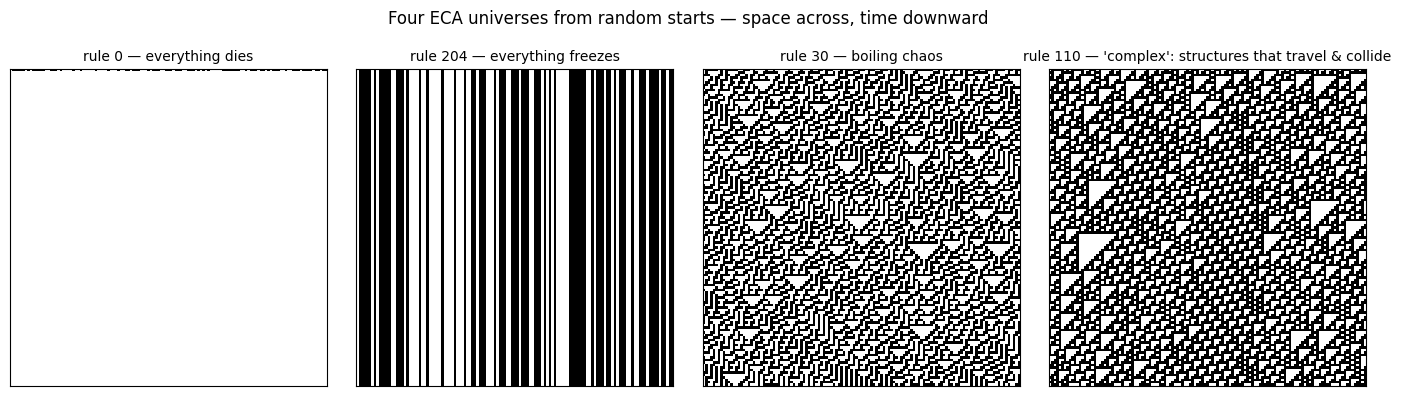

In [1]:
# Environment & imports (MPS fallback on, per CLAUDE.md; everything here is CPU-light).
import os
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")

import warnings
warnings.filterwarnings("ignore")

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

from caspectra.ca.eca import ECASimulator

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
np.random.seed(0); torch.manual_seed(0)


def diagram(rule, size=127, seed=0):
    # One spacetime diagram from a seeded random initial row. Size is odd on
    # purpose: on a power-of-two ring some rules artificially collapse to blank
    # (see notebook 01's "power-of-two trap").
    rng = np.random.default_rng(seed)
    return ECASimulator(rule).random_diagram(width=size, n_steps=size, rng=rng)


SHOWCASE = {
    0:   "rule 0 — everything dies",
    204: "rule 204 — everything freezes",
    30:  "rule 30 — boiling chaos",
    110: "rule 110 — 'complex': structures that travel & collide",
}

fig, axes = plt.subplots(1, 4, figsize=(14, 3.8))
for ax, (rule, title) in zip(axes, SHOWCASE.items()):
    ax.imshow(diagram(rule), cmap="binary", interpolation="nearest")
    ax.set_title(title, fontsize=10); ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Four ECA universes from random starts — space across, time downward", y=1.03)
fig.tight_layout(); plt.show()

A naturalist would immediately sort these: *dead*, *frozen*, *turbulent*, and —
the interesting one — *complex*, where localized structures ("gliders") travel
across an organized background and collide. Rule 110 is famous because those
collisions can be wired up to perform any computation: a Turing-complete
universe in eight bits.

The project's founding question: **can a machine discover this kind of
behavioural sorting on its own, from the images alone, without being told the
rules or the categories?**

## 2. Why the first approach failed: the fingerprint problem

Our first attempt used **self-supervised learning (SSL)** — the family of
methods behind modern image models. The recipe: show a network two slightly
altered copies of the same image and train it to recognize them as "the same
thing". With no labels at all, the network invents its own notion of
similarity, which you then hope aligns with the similarity you care about.

For photographs this works wonderfully. For cellular automata it fails in a
subtle, instructive way. Every rule leaves the same microscopic **texture
fingerprint** in every image it produces — the same little arrangements of
pixels, over and over, because the same eight-bit table generated all of them.
The easiest way for the network to say "these two images are the same thing" is
to read that fingerprint. It's as if we asked someone to sort letters by the
*language* they're written in, and they aced the test by recognizing each
individual *author's handwriting* — every Spanish letter in the pile happened
to be written by one of three people. Right answers, wrong concept, and it
falls apart the moment a new author shows up.

Look how plausible the shortcut is — two images from the *same* rule share fine
texture in a way two behaviourally similar rules do not:

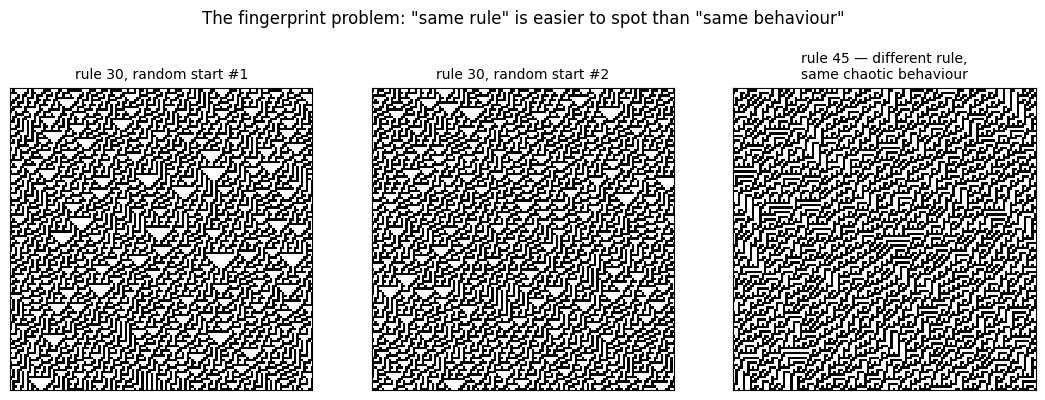

In [2]:
panels = [
    (diagram(30, seed=0), "rule 30, random start #1"),
    (diagram(30, seed=1), "rule 30, random start #2"),
    (diagram(45, seed=0), "rule 45 — different rule,\nsame chaotic behaviour"),
]
fig, axes = plt.subplots(1, 3, figsize=(11, 3.8))
for ax, (img, title) in zip(axes, panels):
    ax.imshow(img, cmap="binary", interpolation="nearest")
    ax.set_title(title, fontsize=10); ax.set_xticks([]); ax.set_yticks([])
fig.suptitle('The fingerprint problem: "same rule" is easier to spot than "same behaviour"', y=1.04)
fig.tight_layout(); plt.show()

We built defences against this (special network architectures, blurring
augmentations — notebook 01 tells that story) and pre-registered a test. The
measured verdict (`RESULTS.md`, 2026-07-01) was unambiguous:

- The trained SSL model could name **the exact rule as well as it could name
  the behaviour class** — the fingerprint won despite every defence.
- Worse: on the metric that matters most — *finding the complex, computing
  rules* — the deep model scored **0.00**, while **four cheap physics
  measurements scored a perfect 1.00** (§3 shows you those four numbers).

Around the same time, a literature review (`FOUNDATIONS.md`) established that
the dream in its strong form — "*the* true behavioural classification,
discovered from images with no assumptions" — is not just hard but **ill-posed**:
provably no algorithm can decide the classic behaviour classes in general, the
observed behaviour genuinely depends on how you set up the experiment (world
size, random-start recipe, observation time), and label-free clustering always
smuggles in *some* notion of similarity. There is no view from nowhere.

So the project pivoted. Not "let the machine discover what behaviour means",
but: **define behaviour operationally, with an experiment — then let the
machine learn to estimate that experiment's outcome cheaply.**

## 3. The butterfly test: measuring behaviour directly

Here is the operational definition, and it is pleasingly physical. Take a
universe, run it. Now rerun it from the *same* random start **with a single
cell flipped** — one pixel of difference, the proverbial butterfly. Evolve both
copies and watch where they disagree (the "**damage**"):

- In a *dead or frozen* universe, the flip heals or stays put.
- In a *chaotic* universe, it explodes outward into a dense, widening cone.
- In a *complex* universe, it does something in between — it survives and
  spreads, but more slowly, carried along by travelling structures rather than
  a wall of noise.

This "damage spreading" experiment is a classic tool from statistical physics,
and it measures exactly the thing the naturalist's eye responds to. Watch it
run on our four showcase universes (right column = where the twins disagree):

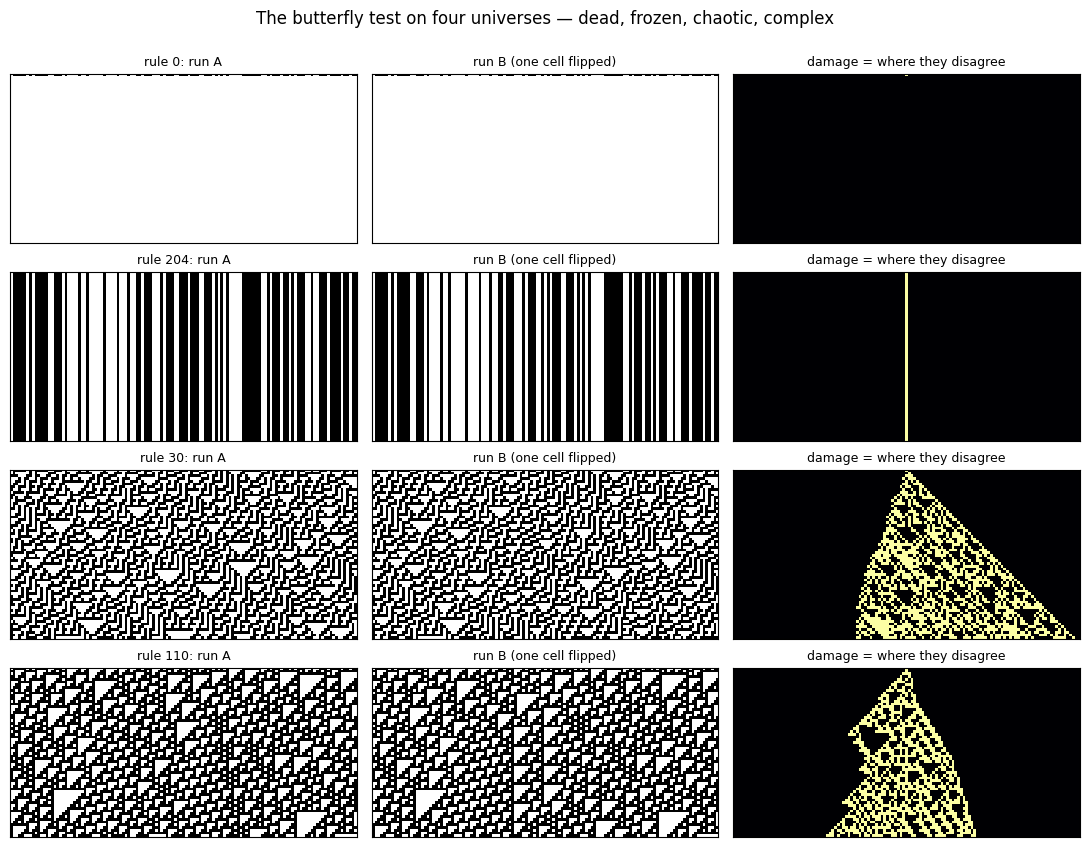

In [3]:
def twin_run(rule, width=127, seed=0):
    # Twin experiment, same conventions as caspectra/eval/dynamics.py:
    # horizon width//2 - 1 keeps the damage cone from wrapping around the ring.
    rng = np.random.default_rng(seed)
    sim = ECASimulator(rule)
    n_steps = width // 2 - 1
    ic = rng.integers(0, 2, size=width, dtype=np.uint8)
    ic_flipped = ic.copy()
    ic_flipped[width // 2] ^= 1  # flip the middle cell
    a = sim.evolve(ic, n_steps)
    b = sim.evolve(ic_flipped, n_steps)
    return a, b, (a != b)


rules = [0, 204, 30, 110]
fig, axes = plt.subplots(4, 3, figsize=(11, 8.5))
for row, rule in enumerate(rules):
    a, b, damage = twin_run(rule)
    for col, (img, cmap, title) in enumerate([
        (a, "binary", f"rule {rule}: run A"),
        (b, "binary", "run B (one cell flipped)"),
        (damage, "inferno", "damage = where they disagree"),
    ]):
        ax = axes[row, col]
        ax.imshow(img, cmap=cmap, interpolation="nearest")
        ax.set_title(title, fontsize=9); ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("The butterfly test on four universes — dead, frozen, chaotic, complex", y=1.0)
fig.tight_layout(); plt.show()

The damage pictures separate the behaviours at a glance: nothing, a single
hairline, a wide fiery cone — and, for rule 110, a **narrower, more ragged
cone** that advances in fits and starts, with voids where the disturbance is
carried by discrete travelling structures instead of raw noise. That
difference in how damage propagates *is* the thing the naturalist's eye was
responding to in §1.

We distil each damage picture into **four numbers** (the "invariants"), asking:

1. **Survival** — did the disturbance survive to the end at all?
2. **Damage fraction** — how much of the world does it touch?
3. **Spreading rate** — how fast does the cone widen? (1.0 = the maximum speed
   information can travel in this universe)
4. **Cone fill** — inside the cone, is the damage *solid* (chaos) or *lacy*
   (travelling structures)?

Because these numbers come from an experiment rather than from labels or
opinion, they are **measurements, not judgements**. Computing them for our
showcase (plus a few more rules):

In [4]:
from caspectra.eval.dynamics import DYNAMICS_FEATURE_NAMES, damage_spreading_features

DEMO = [0, 204, 184, 90, 30, 18, 110, 54]  # 54 is the other famous 'complex' rule
print(f"{'rule':>5} | " + " | ".join(f"{n:>15}" for n in DYNAMICS_FEATURE_NAMES))
print("-" * 79)
rng = np.random.default_rng(0)
for rule in DEMO:
    f = damage_spreading_features(rule, width=127, n_pairs=32, rng=rng)
    print(f"{rule:>5} | " + " | ".join(f"{v:>15.3f}" for v in f))

 rule | damage_survival | damage_fraction |  spreading_rate |       cone_fill
-------------------------------------------------------------------------------
    0 |           0.000 |           0.000 |           0.000 |           0.000
  204 |           1.000 |           0.008 |           0.008 |           1.000
  184 |           1.000 |           0.029 |           0.029 |           1.000
   90 |           1.000 |           0.252 |           0.992 |           0.260
   30 |           1.000 |           0.315 |           0.628 |           0.514
   18 |           0.656 |           0.268 |           0.912 |           0.304
  110 |           0.969 |           0.184 |           0.378 |           0.499


   54 |           1.000 |           0.155 |           0.421 |           0.407


Read the last two rows: rules 110 and 54 — the two celebrated "complex"
universes — sit in a regime of their own. Their damage (nearly) always
survives, like chaos and unlike order; but their cones widen at **less than
half the chaotic pace** (spreading rate ≈ 0.38–0.42, against 0.63–0.99 for
the chaotic rules 30, 18 and 90). No single number does the job — it is the
*combination* that carves out a small in-between region, and that region
contains exactly the famous complex rules. Clustering the 88
essentially-distinct rules on these four numbers groups {54, 110} together
with perfect complex-class recall — the thing the SSL model never managed
(`RESULTS.md`, 2026-07-01).

> **One honest footnote.** These numbers depend on the *experimental protocol* —
> the world size, and especially the density of black cells in the random start.
> We measured this (`RESULTS.md`, criterion 5): the fine-grained sorting of rules
> genuinely shifts if you change the starting-density recipe, exactly as the
> theory literature predicts. So every claim in this project is about behaviour
> *under a stated protocol* (random 50/50 starts, ring of 127 cells, 127 steps) —
> not about "the" behaviour of a rule in the abstract. There is no
> protocol-free classification; the fix is to say your protocol out loud.

## 4. The catch — and the new job for the neural network

If four numbers from a cheap experiment sort the universes so well, why involve
machine learning at all?

Because the butterfly test **needs things you usually don't have**. To run it
you must (a) know the rule, so you can re-run the universe, and (b) be able to
restart the world twice from identical conditions. For ECAs that's trivial. For
the systems this project ultimately cares about — universes whose physics
*varies from place to place* (non-uniform CAs), or a single observed history of
an unknown system — it's impossible. You get **one picture**, no rewind button.

So the network's new job is *estimation*, not discovery: **look at a single
spacetime image and predict what the butterfly test *would* say** — the way a
forester estimates a hillside's flammability from one photograph, without
burning it down twice to compare. In machine-learning jargon this is
**amortization**: pay once, at training time, for many expensive twin-run
experiments; afterwards, get their answer from any single image at a glance.

Two things make this a much better-posed job than the original one:

- The targets are **experimental outcomes**, not human categories — nothing
  subjective is baked in.
- The targets are **honest work**: the four numbers depend on the twin run,
  which the network never sees. It cannot "cheat" by computing them directly
  from its input; it must internalize how each texture *responds* to
  perturbation. (Even the fingerprint shortcut is defanged: reading *which rule
  made this* is now, at worst, a stepping stone to the physics, not a way
  around it.)

## 5. The honest exam: grading only on universes it has never seen

How do you test such a network fairly? Not by asking it about rules it was
trained on — it could just memorize each rule's four numbers. The
pre-registered test (**criterion 6** in `EVALUATION_CRITERIA.md`) is
**leave-rules-out**: hide 18 of the 88 essentially-distinct rules during
training, then ask the network for the invariants of those never-seen
universes and compare against the true twin-run measurements. The agreement
score is R² (1.0 = perfect, 0 = no better than guessing the average);
the bar for success was set at **median R² ≥ 0.5, decided before training**.

Because the complex rules are the scientifically precious ones, we ran the
exam **twice**: once holding out rule 110 (training on 54), and once the other
way around. Below we load the results of both finished runs:

In [5]:
def load_summary(run):
    with open(ROOT / run / "eval" / "summary.json") as fh:
        return json.load(fh)

main, swap = load_summary("runs/lever_a"), load_summary("runs/lever_a_swap")

print("Criterion 6 — rule-level R² on the 18 held-out (never-seen) rules")
print(f"{'invariant':>16} | {'main (110 out)':>15} | {'swap (54 out)':>15}")
print("-" * 54)
for name in DYNAMICS_FEATURE_NAMES:
    print(f"{name:>16} | {main['criterion6_rule_level_r2'][name]:>15.3f} "
          f"| {swap['criterion6_rule_level_r2'][name]:>15.3f}")
print("-" * 54)
print(f"{'median':>16} | {main['criterion6_median_r2']:>15.3f} | {swap['criterion6_median_r2']:>15.3f}")
print(f"{'verdict':>16} | {main['criterion6_verdict']:>15} | {swap['criterion6_verdict']:>15}"
      f"   (pre-registered bar: median ≥ 0.5)")

Criterion 6 — rule-level R² on the 18 held-out (never-seen) rules
       invariant |  main (110 out) |   swap (54 out)
------------------------------------------------------
 damage_survival |           0.694 |           0.700
 damage_fraction |           0.797 |           0.808
  spreading_rate |           0.970 |           0.956
       cone_fill |           0.929 |           0.863
------------------------------------------------------
          median |           0.863 |           0.836
         verdict |            PASS |            PASS   (pre-registered bar: median ≥ 0.5)


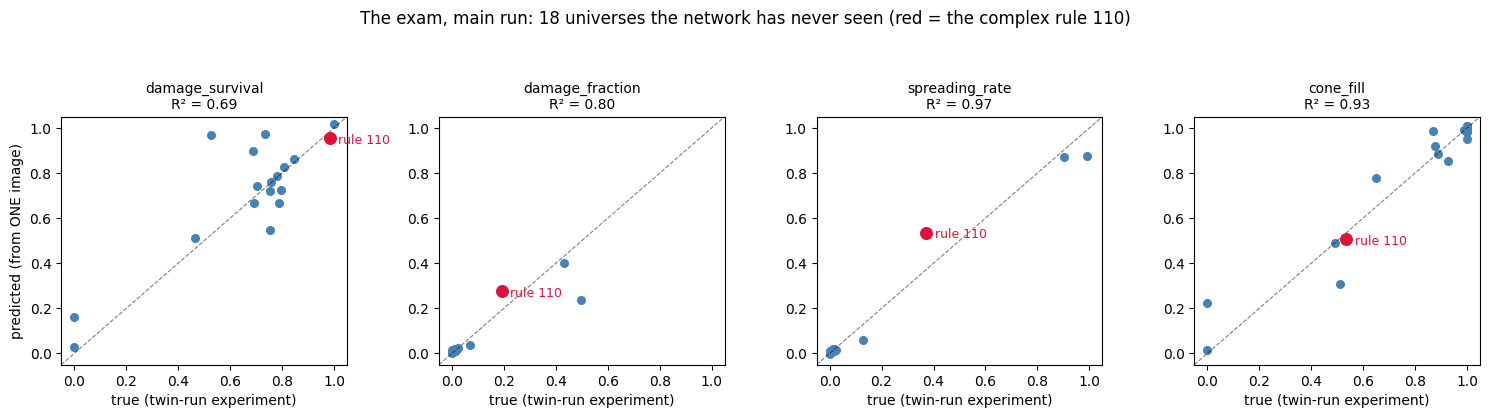

In [6]:
# Predicted vs true, one panel per invariant, over the 18 held-out rules (main run).
per_rule = main["per_held_out_rule"]
fig, axes = plt.subplots(1, 4, figsize=(15, 3.9))
for i, (ax, name) in enumerate(zip(axes, DYNAMICS_FEATURE_NAMES)):
    for rule_str, rec in per_rule.items():
        is_110 = rule_str == "110"
        ax.scatter(rec["true"][i], rec["predicted"][i],
                   c="crimson" if is_110 else "steelblue",
                   s=70 if is_110 else 30, zorder=3 if is_110 else 2)
        if is_110:
            ax.annotate("rule 110", (rec["true"][i], rec["predicted"][i]),
                        textcoords="offset points", xytext=(6, -4), fontsize=9, color="crimson")
    lim = [-0.05, 1.05]
    ax.plot(lim, lim, "k--", lw=0.8, alpha=0.5)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel("true (twin-run experiment)")
    if i == 0:
        ax.set_ylabel("predicted (from ONE image)")
    ax.set_title(f"{name}\nR² = {main['criterion6_rule_level_r2'][name]:.2f}", fontsize=10)
fig.suptitle("The exam, main run: 18 universes the network has never seen (red = the complex rule 110)", y=1.06)
fig.tight_layout(); plt.show()

**Both runs pass, comfortably** (medians 0.863 and 0.836 against a bar of 0.5).
Read the panels: the points hug the diagonal — from a *single* picture of a
universe it has never encountered, the network recovers, with useful accuracy,
what a twin-run perturbation experiment would have measured. Spreading rate is
the star (R² ≈ 0.96–0.97); survival is the weakest (≈ 0.70), largely because it
is nearly all-or-nothing across rules, so small misses are punished harshly.

One more reassurance worth stating: the network reached this accuracy almost
immediately during training, and its internal representation organizes along
≈ 4 directions — essentially the four invariants themselves. It learned the
physics summary, not an 88-entry lookup table.

## 6. The caveat that matters: one complex example is not enough

Now look at the red point above, and at its mirror image in the swapped run:

In [7]:
print("The unseen complex rule, in both runs  (order: "
      + ", ".join(DYNAMICS_FEATURE_NAMES) + ")\n")
for run, summ, held in [("main", main, "110"), ("swap", swap, "54")]:
    rec = summ["per_held_out_rule"][held]
    print(f"{run} run — rule {held} was held out:")
    print(f"   true      {[round(v, 3) for v in rec['true']]}")
    print(f"   predicted {[round(v, 3) for v in rec['predicted']]}\n")

The unseen complex rule, in both runs  (order: damage_survival, damage_fraction, spreading_rate, cone_fill)

main run — rule 110 was held out:
   true      [0.984, 0.192, 0.372, 0.536]
   predicted [0.957, 0.277, 0.536, 0.507]

swap run — rule 54 was held out:
   true      [0.977, 0.178, 0.436, 0.431]
   predicted [0.844, 0.09, 0.185, 0.733]



Both runs misjudge the never-seen complex rule — **in opposite directions**:

- With 110 hidden, its spreading rate is predicted at **0.54 vs a true 0.37** —
  nudged *up*, toward the chaotic rules the network knows well.
- With 54 hidden, its rate is predicted at **0.18 vs a true 0.44** — nudged
  *down*, toward the tamer "locally chaotic" rules.

The pattern is easy to interpret and important: the complex regime sits
*between* order and chaos, and each training set contained exactly **one**
example of it. Asked about an unseen in-between universe, the network does the
sensible statistical thing — it rounds toward the nearest regime it has seen
many examples of. The amortizer passes its exam (the four numbers are recovered
well overall), but a reliable *detector of never-seen complex universes* will
need training data where complexity is not a two-member club. Elementary CAs
simply cannot provide that — there are only ~2 such rules among 88.

This is the strongest quantitative argument yet for the project's next
milestone: **a larger rule space** (bigger neighbourhoods / more states), where
glider-supporting rules are plentiful and the in-between regime can be properly
populated.

## 7. The payoff: behaviour as a *map*, not a single number

Why insist on estimating from a single image? Because a network that does so
convolutionally gives us something the twin-run experiment structurally cannot:
**a spatial map of behaviour**. The trained network summarizes each local patch
of the image before averaging into its final answer — so instead of averaging,
we can read the prediction *at every patch*: a weather map of "how chaotic is
it *here*". (A tidy technical fact: the average of this map is exactly the
network's global prediction — the map is the prediction, unbundled.)

For ordinary ECAs the map is mostly a curiosity — the physics is the same
everywhere. But for **non-uniform CAs**, where different regions follow
different rules, it is the entire point: no twin-run experiment can hand you a
per-region behaviour estimate from one observed history. Let's render the maps
from the trained network:

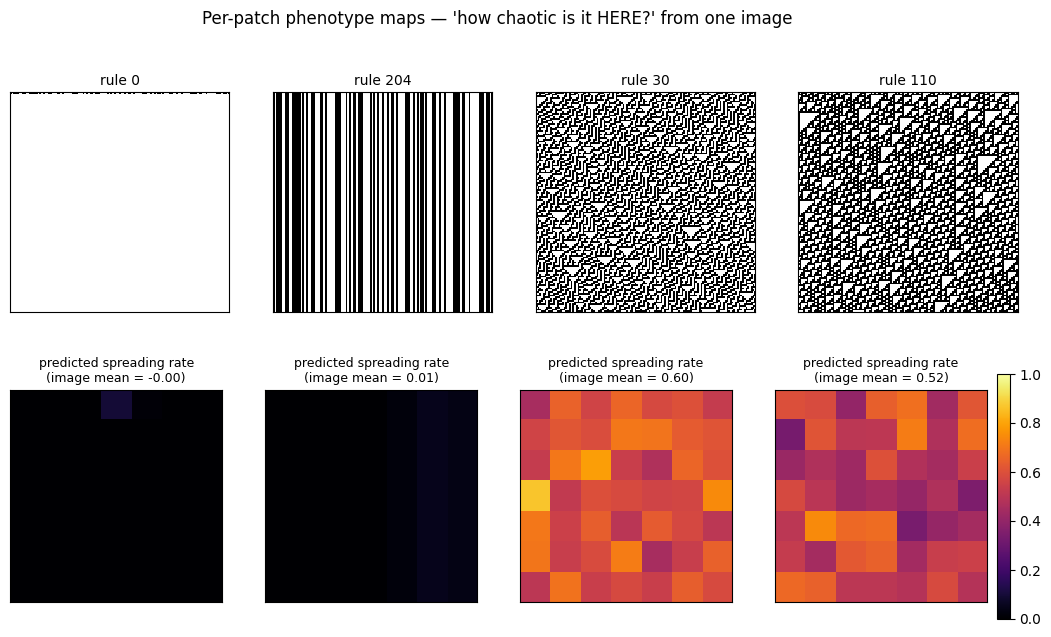

In [8]:
from caspectra.config import ExperimentConfig
from caspectra.factory import build_model

cfg = ExperimentConfig.from_yaml(str(ROOT / "configs/lever_a.yaml"))
ck = torch.load(ROOT / "runs/lever_a/checkpoint_final.pt",
                map_location="cpu", weights_only=False)
model = build_model(cfg.model)
model.load_state_dict(ck["model_state"])
model.eval()

# Predictions are made in standardized-target space; undo with the stored scaler.
mean = torch.tensor(ck["scaler_mean"], dtype=torch.float32)
std = torch.tensor(ck["scaler_std"], dtype=torch.float32)
RATE = DYNAMICS_FEATURE_NAMES.index("spreading_rate")

rules = [0, 204, 30, 110]
fig, axes = plt.subplots(2, 4, figsize=(13, 7))
with torch.no_grad():
    for col, rule in enumerate(rules):
        img = diagram(rule, seed=7)
        x = torch.from_numpy(img).float().unsqueeze(0).unsqueeze(0)
        pmap = model.predict_map(x) * std.view(1, -1, 1, 1) + mean.view(1, -1, 1, 1)
        glob = model(x) * std + mean
        # Consistency identity: the map's mean IS the global prediction.
        assert torch.allclose(pmap.mean(dim=(-2, -1)), model(x) * std + mean, atol=1e-4)
        axes[0, col].imshow(img, cmap="binary", interpolation="nearest")
        axes[0, col].set_title(f"rule {rule}", fontsize=10)
        im = axes[1, col].imshow(pmap[0, RATE].numpy(), cmap="inferno",
                                 vmin=0, vmax=1, interpolation="nearest")
        axes[1, col].set_title(
            f"predicted spreading rate\n(image mean = {glob[0, RATE]:.2f})", fontsize=9)
        for ax in (axes[0, col], axes[1, col]):
            ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=axes[1, :].tolist(), fraction=0.02, pad=0.01)
fig.suptitle("Per-patch phenotype maps — 'how chaotic is it HERE?' from one image", y=0.98)
plt.show()

The maps behave as physics says they should: rule 0's map is near zero
everywhere, with only a faint trace along the top rows where the initial
flurry dies out; rule 204 reads cold; rule 30 reads hot. And the last panel
quietly replays §6 in spatial form: this checkpoint is the *main* run, which
never saw rule 110 — its map reads too hot (image mean ≈ 0.52 against a true
rate of 0.37), the one-complex-example bias made visible.

The current resolution is coarse (the encoder pools the 127×127 image down to
≈ 8×8 patches — each pixel of the map summarizes a ~16-cell neighbourhood), so
treat these as a proof of principle. A shallower prediction head for
finer maps, and a quantitative test on genuinely non-uniform CAs, are the
known next steps on this thread.

## 8. Scoreboard and what's next

Everything measured so far, in one table (details and dates in `RESULTS.md`):

| Question | Verdict |
|---|---|
| Can texture-SSL discover the behaviour classes label-free? | **No** — it identifies rules, not behaviour (gap ≈ 0; complex-class recall 0.00). Kept as the frozen negative baseline. |
| Is a "true", assumption-free classification even well-posed? | **No** (literature): undecidable in general, protocol-dependent, no bias-free clustering. Claims are now protocol-explicit. |
| Do four twin-run invariants sort behaviour well? | **Yes** — complex-class recall 1.00, interpretable regimes, {54, 110} robustly grouped under the stated protocol. |
| Are those invariants predictable from a *single* image of a never-seen rule? | **Yes** — pre-registered criterion 6 **passed twice** (median R² 0.863 / 0.836 vs bar 0.5). |
| Does one complex training example suffice to place an unseen complex rule? | **No** — mirror-image misses for 110/54; complexity needs a populated regime. |
| Can behaviour be mapped *spatially* from one image? | **Qualitatively yes** — coarse (≈ 8×8) but physically sensible phenotype maps. |

**Open directions**, roughly in order of leverage:

1. **A larger rule space** — more states/neighbours, where complex rules are
   plentiful: fixes the two-member-club problem of §6 and breaks the last
   rule-vs-behaviour confounds.
2. **Richer invariants** — extend the target family (e.g. Lyapunov-spectrum
   estimates) so "behaviour" is a fuller experimental profile.
3. **Sharper phenotype maps + non-uniform CAs** — the quantitative version of
   §7, on universes whose physics actually varies in space.
4. **Predictive self-supervision** — the one remaining "discovery-flavoured"
   lever (predict the *future* of a diagram rather than compare augmented
   views); strictly optional now, with pre-registered kill criteria.

The one-line summary of the pivot: **we stopped asking the network to invent
the science, and started asking it to speed up the experiment.** That question,
it turns out, it can answer.